ThinCurr Python Example: Compute eigenstates in a plate {#doc_tCurr_plate_eig}
==========
In this example we demonstrate how to compute eigenvalues and eigenvectors for a simple ThinCurr model.

**Note:** Running this example requires the [h5py](https://www.h5py.org/) and [pyvista](https://pyvista.org/) python packages, which are installable using `pip` or other standard methods.

In [1]:
import struct
import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
try:
    import pyvista
    pyvista.set_jupyter_backend('static') # Comment to enable interactive PyVista plots
    have_pyvista = True
except ImportError:
    have_pyvista = False
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load ThinCurr library

To load the ThinCurr python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` for binaries on macOS).

In [2]:
thincurr_python_path = os.getenv('OFT_ROOTPATH')
if thincurr_python_path is not None:
    sys.path.append(os.path.join(thincurr_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.ThinCurr import ThinCurr

## Compute eigenvalues

### Setup ThinCurr model
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.ThinCurr.ThinCurr "ThinCurr" instance that utilizes that execution environment.

Once created, we setup the model from an existing HDF5 and XML mesh definition using \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.setup_model "setup_model()".

Finally, we initialize I/O for this model using \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.setup_io "setup_io()" to enable output of plotting files for 3D visualization in [VisIt](https://visit-dav.github.io/visit-website/index.html), [Paraview](https://www.paraview.org/), or using [pyvista](https://pyvista.org/) below.

In [3]:
myOFT = OFT_env(nthreads=2)
tw_plate = ThinCurr(myOFT)
tw_plate.setup_model(mesh_file='thincurr_ex-plate.h5',xml_filename='oft_in.xml')
tw_plate.setup_io()

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v1.0.0-beta7
Development branch:  release_26_06
Revision id:         978c4b9f

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------


Creating thin-wall model
  No V(t) driver coils found
  Loading I(t) driver coils
    Masked      0 coils from sensors
  Building holes

  Loading region surface resistivity:
     1  1.2570E-05

  Setup complete:
    # of points    =          492
    # of edges     =         1393
    # of cells     =          902
    # of holes     =            0
    # of closures  =            0
    # of Vcoils    =            0
    # of Icoils    =            1


### Compute self-inductance and resistivity matrices
With the model setup, we can now compute the self-inductance and resistivity matrices. A numpy version of the self-inductance matrix will be stored at \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.Lmat "tw_plate.Lmat". By default the resistivity matrix is not moved to python as it is sparse and converting to dense representation would require an increase in memory. These matrices correspond to the $\textrm{L}$ and $\textrm{R}$ matrices for the physical system

$\textrm{L} \frac{\partial I}{\partial t} + \textrm{R} I = V$

**Note:** For larger models calculating the self-inductance may take some time due to the $N^2$ interaction of the elements (see \ref doc_tCurr_hodlr for more information).

In [4]:
tw_plate.compute_Lmat()
tw_plate.compute_Rmat()

Building element<->element self inductance matrix
  Time =  0s          
Building resistivity matrix


### Compute eigenvalues/eigenvectors for the plate model
With $\textrm{L}$ and $\textrm{R}$ matrices we can now compute the eigenvalues and eigenvectors of the system $\textrm{L} I = \lambda \textrm{R} I$, where the eigenvalues $\lambda = \tau_{L/R}$ are the decay time-constants of the current distribution corresponding to each eigenvector.

In [5]:
eig_vals, eig_vecs = tw_plate.get_eigs(5,False)


Starting eigenvalue solve (ARPACK)
  Time =   3.2170E-03
  Eigenvalues
      9.732856E-03
      6.530427E-03
      6.530315E-03
      5.250082E-03
      4.703101E-03


### Save data for plotting
The resulting currents can be saved for plotting using \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.save_current "tw_plate.save_current()". Here we save each of the five eigenvectors for visualization. Once all fields have been saved for plotting \ref OpenFUSIONToolkit.ThinCurr.ThinCurr.build_XDMF "tw_plate.build_XDMF()" to generate the [XDMF descriptor files](https://www.xdmf.org/index.php/XDMF_Model_and_Format) for plotting with VisIt of Paraview. This method also returns a \ref OpenFUSIONToolkit.io.XDMF_plot_file "XDMF_plot_file" object, which can be used to read and interact with plot data in Python (see below).

In [6]:
tw_plate.save_current(eig_vecs[0,:],'J_01')
tw_plate.save_current(eig_vecs[1,:],'J_02')
tw_plate.save_current(eig_vecs[2,:],'J_03')
tw_plate.save_current(eig_vecs[3,:],'J_04')
plot_data = tw_plate.build_XDMF()


Creating output files: oft_xdmf.XXXX.h5
  Removing old Xdmf files
    Removed 2 files
  Found Group: thincurr
    Found Mesh: icoils
    Found Mesh: smesh


## Plot current vectors on surface
Finally we plot the current vectors on the plate showing the longest-lived eddy current structure, which corresponds to a large circulation on the plate. The \ref OpenFUSIONToolkit.io.XDMF_plot_file "XDMF_plot_file" class provides functionality to work with the data stored in OFT plot files, including methods to generate information for 3D plotting in Python using [pyvista](https://pyvista.org/).

Plotting data is always associated with a specific mesh, which is itself associated with a physics group. In this case `ThinCurr` is the physics group and the data we are interested in is stored on the surface mesh `smesh`. The `plot_data['ThinCurr']['smesh']` is a \ref OpenFUSIONToolkit.io.XDMF_plot_mesh "XDMF_plot_mesh" object with further functionality for accessing data.

To plot the first eigenvector we first get the pyvista plotting grid using \ref OpenFUSIONToolkit.io.XDMF_plot_mesh.get_pyvista_grid() "get_pyvista_grid()" and then retrieve the vertex-centered field (`J_01_v`) using \ref OpenFUSIONToolkit.io.XDMF_plot_mesh.get_field() "get_field()"

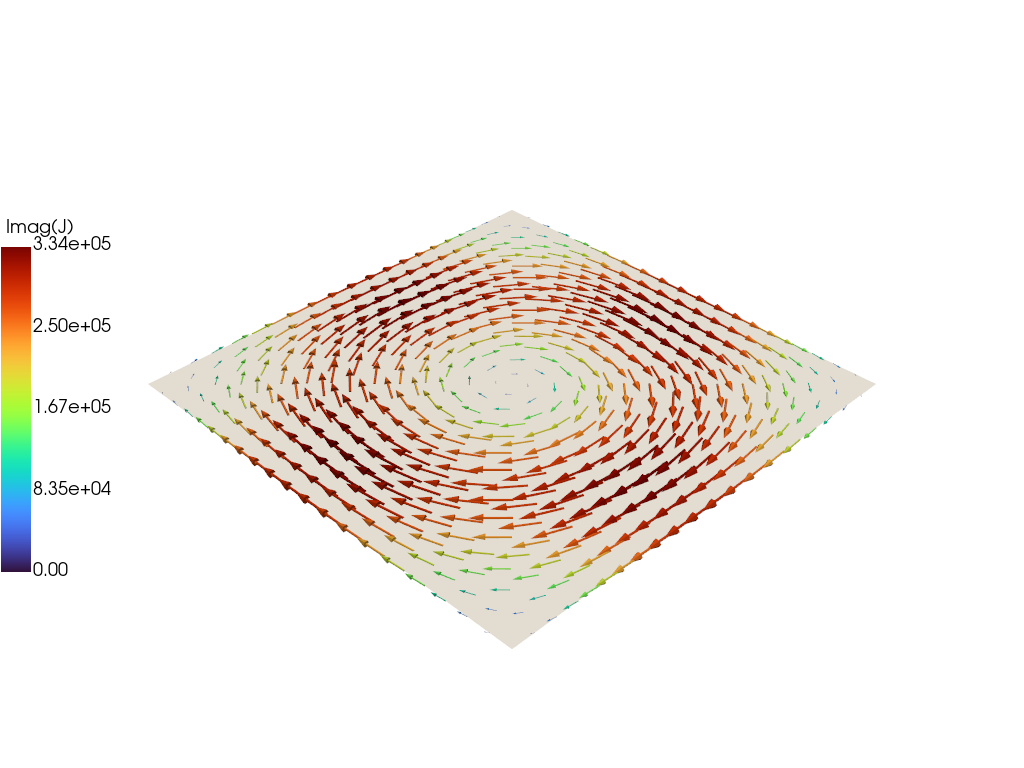

In [7]:
if have_pyvista:
    grid = plot_data['ThinCurr']['smesh'].get_pyvista_grid()
    J_01 = plot_data['ThinCurr']['smesh'].get_field('J_01_v')

    grid["vectors"] = J_01
    grid.set_active_vectors("vectors")

    p = pyvista.Plotter()
    scale = 0.1/(np.linalg.norm(J_01,axis=1)).max()
    arrows = grid.glyph(scale="vectors", orient="vectors", factor=scale)
    p.add_mesh(arrows, cmap="turbo", scalar_bar_args={'title': "Imag(J)", "vertical": True, "position_y":0.25, "position_x": 0.0})
    p.add_mesh(grid, color="white", opacity=1.0, show_edges=False)
    p.show(jupyter_backend='static')